In [ ]:
!pip install -q tensorflow==2.15.0 pandas scikit-learn numpy==1.26.4

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving encoded-First_draft_dataset.csv to encoded-First_draft_dataset (3).csv


In [ ]:
import pandas as pd
import io

df = pd.read_csv(io.BytesIO(uploaded['encoded-First_draft_dataset (3).csv']))
df.head()

,text,label
0,am I supposed to take a dose,ask_med_details
1,am I supposed to take any pills,ask_med_details
2,am I supposed to take any pills right now,ask_med_details
3,am I supposed to take anything now,ask_med_details
4,am I taking any pills at the moment,ask_med_details


In [ ]:
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GlobalAveragePooling1D # Added GAP1D
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split


##rnn

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Bidirectional

##


# Assuming df['text'] and df['label'] are available
texts = df['text'].astype(str).tolist()
labels = df['label'].astype(str).tolist()

# Tokenize text
tokenizer = Tokenizer(num_words=1000, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
max_len = 15 # Your chosen max_len is good
X = pad_sequences(sequences, maxlen=max_len)

# Encode labels
le = LabelEncoder()
y = le.fit_transform(labels)
num_classes = len(le.classes_)

# Correct vocab_size for Embedding layer
vocab_size = tokenizer.num_words + 1 # 1000 words + 1 for OOV token

# --- Model Option 1: Simplified LSTM ---
#model = Sequential([
 #   Embedding(input_dim=vocab_size, output_dim=32, input_length=max_len), # Smaller embedding
  #  LSTM(32), # Single, smaller LSTM layer
  #  Dropout(0.4), # Increased dropout
   # Dense(num_classes, activation='softmax') # Directly to output layer
#])

# --- Model Option 2: Global Average Pooling (Even simpler for TinyML) ---
#model = Sequential([
#     Embedding(input_dim=vocab_size, output_dim=32, input_length=max_len),
#     GlobalAveragePooling1D(), # Use Global Average Pooling
#     Dropout(0.4),
#     Dense(32, activation='relu'), # Optional: smaller dense layer
#     Dropout(0.3), # Optional: dropout before final
#     Dense(num_classes, activation='softmax')
# ])
# -------Model 3 RNN -----------------#

# Assuming vocab_size, max_len, num_classes are defined from your dataset
# Embedding output_dim increased for more parameters and richer representations
embedding_output_dim = 96 # Or 128 to push parameter count higher


model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_output_dim, input_length=max_len),
    # SWAP OUT GlobalAveragePooling1D for the Bidirectional GRU/LSTM layer
    Bidirectional(GRU(64, return_sequences=False)), # GRU units (e.g., 64) - adjust based on param budget and performance
    Dropout(0.4), # Dropout after RNN layer
    Dense(64, activation='relu'), # Intermediate Dense layer
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=['accuracy'])

# Print model summary to see the number of parameters
model.summary()

# Split data (already good)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Early stopping (already good)
es = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val), # Correct: Pass validation_data directly
    epochs=30, # Max epochs, but early stopping will handle it
    batch_size=16,
    verbose=1,
    callbacks=[es]
)

# You can then plot history.history['accuracy'], history.history['val_accuracy'], etc.
# to see the new learning curves.

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 15, 96)            96096     
                                                                 
 bidirectional (Bidirection  (None, 128)               62208     
 al)                                                             
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 8)                 520       
                                                      

In [ ]:
import numpy as np
def predict_label(prompt):
    seq = tokenizer.texts_to_sequences([prompt])
    pad_seq = pad_sequences(seq, maxlen=max_len)
    pred = np.argmax(model.predict(pad_seq), axis=1)
    return le.inverse_transform(pred)[0]

# Examples
print(predict_label("whats the weather"))
print(predict_label("Do you know the time this afternoon"))
print(predict_label("Yes, I took them"))
print(predict_label("No, I haven’t taken them"))
print(predict_label("When should I take my meds?"))
print(predict_label("is it time for my pills yet"))
print(predict_label("what medicines should I take"))
print(predict_label("remind me agian in 10 minutes"))
print(predict_label("I will take them later"))
print(predict_label("now??"))
print(predict_label("what"))

1/1 [==============================] - 2s 2s/step
irrelevant
1/1 [==============================] - 0s 70ms/step
ask_time
1/1 [==============================] - 0s 93ms/step
confirm_taken
1/1 [==============================] - 0s 83ms/step
deny_taken
1/1 [==============================] - 0s 97ms/step
ask_schedule
1/1 [==============================] - 0s 36ms/step
ask_schedule
1/1 [==============================] - 0s 38ms/step
ask_med_details
1/1 [==============================] - 0s 37ms/step
remind_later
1/1 [==============================] - 0s 49ms/step
remind_later
1/1 [==============================] - 0s 56ms/step
irrelevant
1/1 [==============================] - 0s 24ms/step
irrelevant


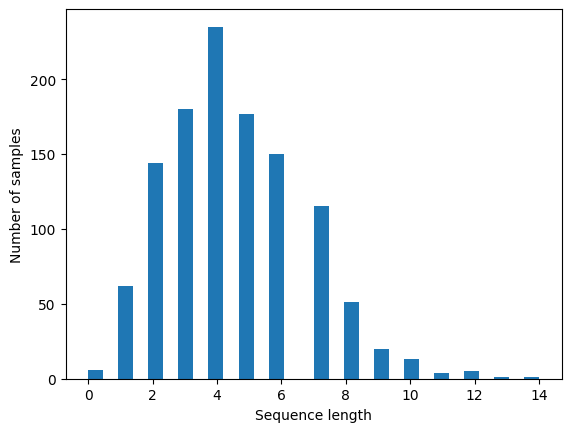

Max length: 14
Median length: 4.0
90th percentile length: 7.0


In [ ]:
sequences = tokenizer.texts_to_sequences(texts)
lengths = [len(seq) for seq in sequences]

import matplotlib.pyplot as plt
plt.hist(lengths, bins=30)
plt.xlabel('Sequence length')
plt.ylabel('Number of samples')
plt.show()

print(f"Max length: {max(lengths)}")
print(f"Median length: {np.median(lengths)}")
print(f"90th percentile length: {np.percentile(lengths, 90)}")

In [ ]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 15, 96)            96096     
                                                                 
 bidirectional (Bidirection  (None, 128)               62208     
 al)                                                             
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 8)                 520       
                                                      

In [ ]:
text = ["Did I take my morning medicine?"]

# Convert text to sequence of integers (word indexes)
seq = tokenizer.texts_to_sequences(text)

# Pad sequence to max_len
padded_seq = pad_sequences(seq, maxlen=max_len, padding='post')

print(padded_seq)

[[18  3  4 11 42  8  0  0  0  0  0  0  0  0  0  0  0  0  0  0]]


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np # Import numpy if not already imported

# y_true and y_pred are your true and predicted labels for the validation set
# Use y_val as the true labels
y_true = y_val

# Make predictions on the validation set
# model.predict returns probabilities, so use np.argmax to get the predicted class index
y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)

# Now y_true and y_pred are defined and contain the labels and predictions for the validation set
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

8/8 [==============================] - 0s 6ms/step
[[23  0  0  0  0  1  0  0]
 [ 2 26  0  0  0  0  0  0]
 [ 0  0 22  0  0  2  0  0]
 [ 0  0  0 41  0  1  0  0]
 [ 0  0  0  0 39  0  0  0]
 [ 0  0  1  1  0 22  0  0]
 [ 0  0  0  0  3  6 17  0]
 [ 0  0  0  0  0  0  0 26]]
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        24
           1       1.00      0.93      0.96        28
           2       0.96      0.92      0.94        24
           3       0.98      0.98      0.98        42
           4       0.93      1.00      0.96        39
           5       0.69      0.92      0.79        24
           6       1.00      0.65      0.79        26
           7       1.00      1.00      1.00        26

    accuracy                           0.93       233
   macro avg       0.93      0.92      0.92       233
weighted avg       0.94      0.93      0.93       233



In [ ]:
def predict_label(text):
    seq = tokenizer.texts_to_sequences([text])
    padded_seq = pad_sequences(seq, maxlen=max_len, padding='post')
    interpreter.set_tensor(input_details[0]['index'], padded_seq.astype(input_details[0]['dtype']))
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    pred_index = np.argmax(output, axis=1)[0]
    pred_label = le.inverse_transform([pred_index])[0]
    return pred_label

# Test prompt
prompt = "	Don't forget your medication."
print("Prompt:", prompt)
print("Predicted label:", predict_label(prompt))

Prompt: 	Don't forget your medication.
Predicted label: confirm_taken


In [ ]:
print(df['label'].value_counts())

label
notify_take_meds        10
ask_intake_status       10
confirm_taken           10
deny_taken              10
delay_intake            10
ask_medicine_time       10
delay_request           10
ask_time_context        10
ask_schedule_context    10
irrelevant              10
Name: count, dtype: int64


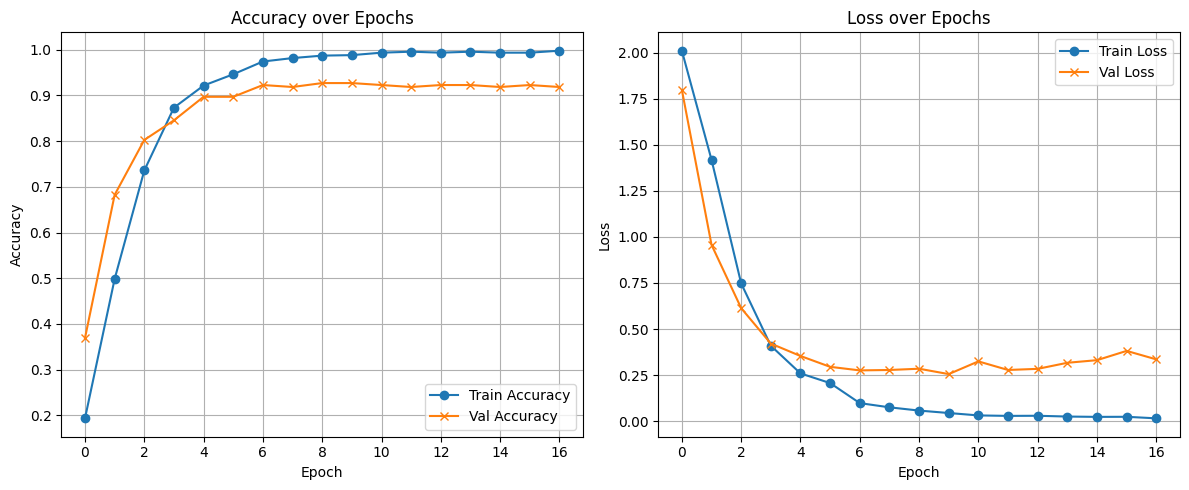

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='x')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='x')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
original_labels = le.classes_
print("Mapping of integer labels to original text labels:")
for i, label_name in enumerate(original_labels):
    print(f"Integer Label {i}: {label_name}")

Mapping of integer labels to original text labels:
Integer Label 0: ask_med_details
Integer Label 1: ask_schedule
Integer Label 2: ask_time
Integer Label 3: confirm_taken
Integer Label 4: deny_taken
Integer Label 5: irrelevant
Integer Label 6: notify_sos
Integer Label 7: remind_later
